In [1]:
import pvlib
import pypsa
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np


In [2]:
# ---- Eingaben ----
nc_path = "/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten_Julian/ecmwf_sfc_2019-01-01_00.grb"     # dein TIGGE NetCDF (muss ssrd & t2m enthalten)

pdc0 = 1000.0                    # 1 kW_DC Nameplate, in Watt (Basis für CF)

# ---- TIGGE laden ----


In [9]:
import glob
liste = []

def calculate_cf_factor(ds: xr, albedo=0.2):

    ds['ssr'] = ds['ssr'] / (1-albedo)                 # albedo factor --> yes / no?

    ds = ds.diff('step')  # J/m²                    # TIGGE has accumulated values, therefore the difference 
                                                    # is the actual radiation in J / m^2

    ds = (ds/3600).fillna(0).clip(min=0)            # get Wh / m^2
    ds = ds.where(ds > 1, 0)

    ds['cf'] = 0.9 * ds['ssr'] / (6 * pdc0)         # as everything is in 6 hours divide by 6
                                                    # as we accumulate 3 hours, multiply by 3. 

    return ds['cf']


def get_pypsa_export_structure(data: xr):

    cf = []

    for i in range(0, data.number[-1].values):
        index = pd.date_range(
            start="2019-01-01 00:00",
            # CHANGE END HERE
            end="2020-01-02 00:00",
            freq="3h"
        )

        df = pd.DataFrame(index=index)
        df[f'cf_solar_{i+1}'] = np.NaN

        for data_chunk in data:
            dt = data_chunk['valid_time'].values
            dt_str = pd.to_datetime(dt).strftime("%Y-%m-%d %H:%M:%S")  
            df.loc[dt_str, f'cf_solar_{i+1}'] = data_chunk[i].values

        #df[f'cf_solar_{i+1}'] = df[f'cf_solar_{i+1}'].interpolate(method="linear")
        mask = (df.index.time >= pd.to_datetime("08:00").time()) & (df.index.time <= pd.to_datetime("19:00").time())
        df.loc[mask, f'cf_solar_{i+1}'] = df.loc[mask, f'cf_solar_{i+1}'].interpolate(method='linear')
        
        df = df.fillna(0)
        cf.append(df)

    return cf


def get_pv_capacity_factor():

    for file_name in glob.glob("/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/ECWMF_Data/*.grb"):
        solar_data = xr.open_dataset(
                file_name,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "paramId": [167, 176],
                    }
                }
            )
        #data_chunk = solar_data.loc[{'latitude': 53.0, 'longitude': 10.0}]
        data_chunk = solar_data.mean(dim=("latitude", "longitude"))

        cf = calculate_cf_factor(data_chunk)
        cf.expand_dims(time=[str(data_chunk['time'].values)[:10]])

        liste.append(cf)

    data = xr.concat(liste, dim='time')
    data = data.sortby("time")

    data = get_pypsa_export_structure(data)

    return data

In [10]:
cf_list = get_pv_capacity_factor()

In [11]:
for i in range(0,50):
    cf_list[i] = cf_list[i].loc[:'2019-12-31 22:00']

In [2]:
n = pypsa.Network('/Users/mick/Documents/GitHub/masterthesis-mick/base_s_1__none_2035_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [3]:
cf_list = pd.read_pickle('/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_solar.pkl')

<Axes: xlabel='snapshot'>

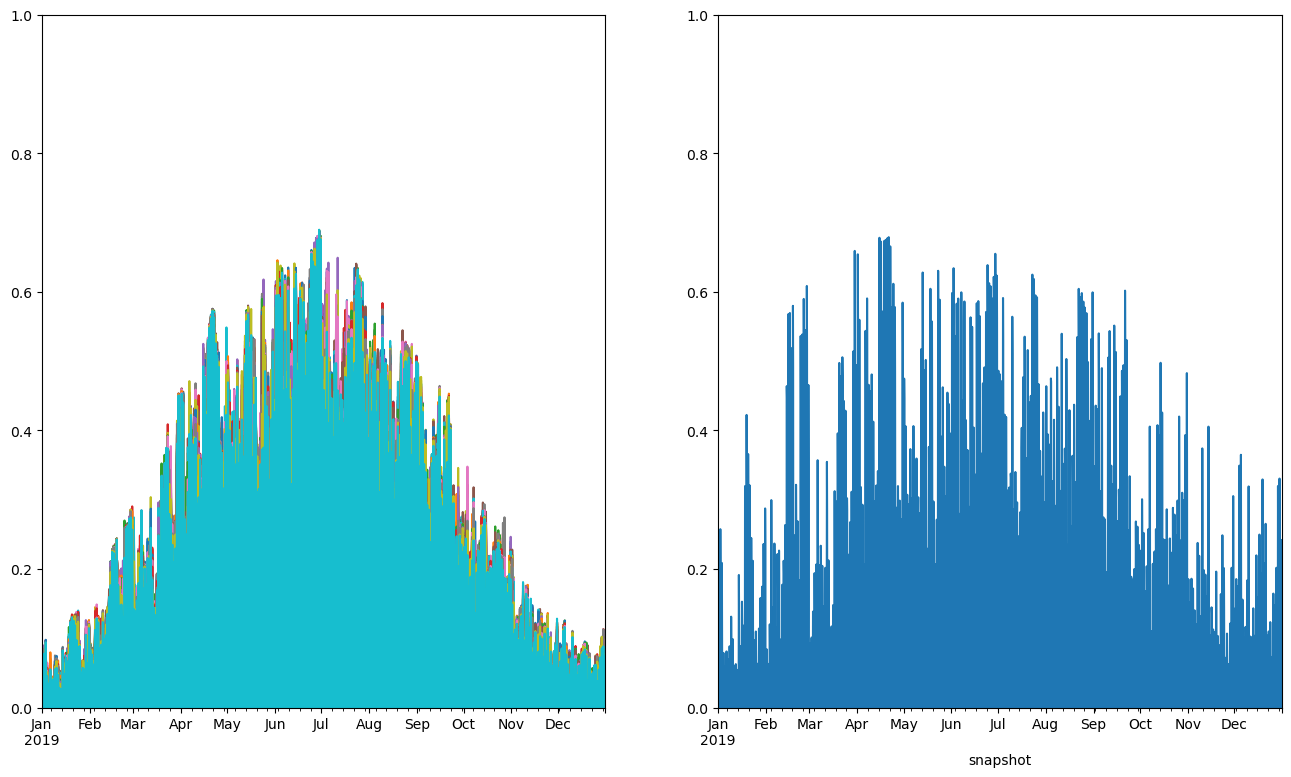

In [4]:
fig, ax = plt.subplots(1,2, figsize=(16,9))

for i in range(0, 50):
    cf_list[i].plot(
        ax = ax[0],
        ylim=(0,1),
        legend=False
    )


n.generators_t.p_max_pu['DE0 0 solar-2035'].plot(
    ax=ax[1],
    ylim=(0,1)
)

In [15]:
pd.to_pickle(cf_list, "/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_solar.pkl")